In [1]:
!git clone https://github.com/stiflet/CandidateProject.git
!hf download Stiflet/WeatherData --repo-type=dataset --local-dir=Weather_Models

Cloning into 'CandidateProject'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 46 (delta 13), reused 40 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 4.82 MiB | 3.59 MiB/s, done.
Resolving deltas: 100% (13/13), done.
A new version of huggingface_hub (1.10.1) is available! You are using version 1.8.0.
To update, run: pip install -U huggingface_hub

Fetching 8 files:   0% 0/8 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Fetching 8 files: 100% 8/8 [00:04<00:00,  1.92it/s]
Download complete: : 185MB [00:04, 67.5MB/s]              /content/Weather_Models
Download complete: : 185MB [00:04, 43.2MB/s]


In [8]:


!git reset --soft HEAD~1
!git restore --staged .

# after you have cleaned Models/EMOS/EMOS.ipynb:
!git add Models/EMOS/EMOS.ipynb
!git add .
!git commit -m "Remove secret from notebook"
!git push origin main

[main a99823b] Remove secret from notebook
 2 files changed, 873 insertions(+)
 delete mode 100644 EMOS_notebook.pdf
 create mode 100644 Models/EMOS/EMOS.ipynb
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (5/5), 19.35 KiB | 6.45 MiB/s, done.
Total 5 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-th

# Ensemble Model Output Statistics (EMOS)
EMOS is one of the most commonly used baseline models in the probabilistic forecasting literature.

## Overview
EMOS is a method used for estimating a full probability distribution over a continuous variable. It does so by using ensemble forecasts, where the predictive mean is modeled as a function of the ensemble mean and the predictive variance is modeled as a function of the spread between the ensemble members.

## Mathematical definition
Let

$y=$ observed value of the target variable.

$x_1, x_2, \dots, x_M$ = ensemble member forecasts of the target variable.

Then for the variable temperature as in the example below, the predictive distribution is often assumed to be:

$y \mid x_1, x_2, \dots, x_M \sim \mathcal{N}(\mu, \sigma^2)$ e.g. Guassian


where the predictive mean $\mu$ and predictive variance $\sigma^2$ are modeled as

$\mu = a + b \bar{x}$

$\sigma^2 = c + d S^2$


where

$\bar{x} = \frac{1}{M}\sum_{m=1}^M x_m$ is the ensemble mean.

$S^2 = \frac{1}{M-1}\sum_{m=1}^M (x_m - \bar{x})^2$ is the ensemble variance.

The parameters a,b,c and d are estimated from historical forecast and observation data. This allows EMOS to correct where the forecast is centered and how uncertain it is, which often makes the forecast more reliable than the raw ensemble output.

In [ ]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import numpy as np

#I have gathered historical forecast and observations of different variables
#for the latitude longitude pair closest to LaGuardia airport in New York City.
#The model used is Global Ensemble Forecast Systems (GEFS).
#The provider had the following available in their zarr library (https://dynamical.org/catalog/noaa-gefs-forecast-35-day/):
  #Spatial domain: 	Global
  #Spatial resolution:
    #0-240 hours: 0.25 degrees (~20km),
    #243-840 hours: 0.5 degrees (~40km)
  #Time domain:
  	#Forecasts initialized 2020-10-01 00:00:00 UTC to Present
  #Time resolution:
  	#Forecasts initialized every 24 hours
  #Forecast domain:
  	#Forecast lead time 0-840 hours (0-35 days) ahead
  #Forecast resolution:
  	#Forecast step 0-240 hours: 3 hourly,
    #243-840 hours: 6 hourly
#The data has been cleaned and split up in 4 different parquet files each with 4 different leadtimes.
  #3h
  #6h
  #9h
  #12h
#The variable used for this EMOS is maximum temperature at 2 meters height, and contains 31 ensemble members.
df = pd.read_parquet(r"/content/Weather_Models/Preprocessing/EMOS/emos_3h.parquet").dropna().sort_index()


ensemble_members = df.drop('obs', axis=1)
observations = df['obs']
df

ensemble_member,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,obs
valid_time,,,,,,,,,,,,,,,,,,,,,
2020-10-01 03:00:00+00:00,20.00000,19.7500,20.0000,20.0000,20.00000,19.87500,20.12500,20.00000,20.1250,19.87500,...,20.2500,19.8750,20.12500,20.12500,20.1250,20.0000,19.8750,19.62500,20.0000,18.888889
2020-10-02 03:00:00+00:00,20.87500,20.7500,21.2500,21.2500,21.12500,21.00000,21.00000,20.50000,20.6250,20.62500,...,20.8750,20.8750,20.62500,21.12500,20.6250,21.2500,20.8750,21.25000,20.2500,20.000000
2020-10-03 03:00:00+00:00,18.12500,18.2500,18.1250,18.1250,18.37500,18.25000,18.25000,18.25000,18.2500,18.12500,...,18.1250,18.1250,18.37500,18.12500,18.1250,18.0000,17.7500,18.12500,18.2500,15.555556
2020-10-04 03:00:00+00:00,17.62500,17.8750,17.2500,17.1250,17.75000,17.25000,17.62500,18.00000,17.7500,18.00000,...,17.8750,18.1250,17.62500,17.62500,17.5000,17.6250,17.7500,17.75000,17.6250,15.555556
2020-10-05 03:00:00+00:00,17.37500,17.3750,17.2500,17.3750,17.25000,17.25000,17.25000,17.50000,17.2500,17.50000,...,17.5000,17.2500,17.25000,17.25000,17.5000,17.3750,17.0000,17.50000,17.3750,16.111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-01 03:00:00+00:00,19.87500,20.0000,20.0000,20.2500,20.75000,18.87500,20.25000,19.25000,20.2500,20.50000,...,19.2500,19.2500,20.12500,20.50000,20.0000,20.3750,19.7500,18.37500,20.2500,18.888889
2026-04-02 03:00:00+00:00,15.87500,15.5000,16.3750,15.1875,16.25000,15.75000,16.62500,16.25000,16.7500,16.12500,...,15.8125,16.1250,15.62500,15.12500,16.5000,15.5625,15.6250,16.25000,14.6875,11.111111
2026-04-03 03:00:00+00:00,6.90625,7.1250,7.0000,7.4375,7.40625,7.28125,6.46875,6.78125,7.0000,7.21875,...,7.4375,7.0000,6.15625,6.90625,7.3750,6.4375,6.6250,6.65625,6.6875,5.000000


In [ ]:
from scipy.stats import norm
import numpy as np

def crps_ensemble(obs, ensemble): #CRPS for an ensemble forecast.
    obs = np.asarray(obs) #Convert observations to numpy array.
    ensemble = np.asarray(ensemble) #Convert ensemble forecasts to numpy array.

    term1 = np.mean(np.abs(ensemble - obs[:, None]), axis=1) #Average absolute difference between each observation and its ensemble members.
    term2 = 0.5 * np.mean(
        np.abs(ensemble[:, :, None] - ensemble[:, None, :]), #Average pairwise absolute difference between ensemble members.
        axis=(1, 2)
    )
    return term1 - term2 #CRPS formula for an ensemble forecast.


def crps_gaussian(obs, mu, sigma): #CRPS for a Gaussian predictive distribution.
    z = (obs - mu) / sigma #Standardize the observations relative to the Gaussian forecast.
    return sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi)) #Closed form Gaussian CRPS.




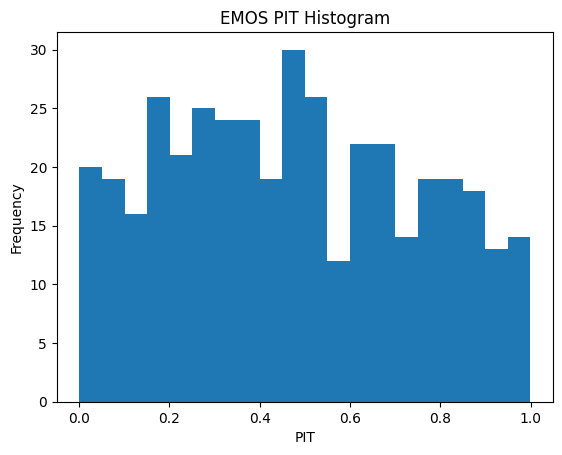

Raw ensemble mean CRPS: 1.2193328261628436
EMOS mean CRPS: 0.7797105025018866
CRPS improvement (raw - EMOS): 0.439622323660957


In [ ]:

ensemble_members = df.drop(columns=["obs"]) #Drop the observation column for training.
observations = df["obs"]

split = int(len(df) * 0.8) #Splitting the data 80% train 20% test.

X_train = ensemble_members.iloc[:split]
y_train = observations.iloc[:split]

X_test = ensemble_members.iloc[split:]
y_test = observations.iloc[split:]

def emos(params, observations, ensemble_members): #Function for optimizing a,b,c and d.
    a, b, c, d = params

    ens_mean = ensemble_members.mean(axis=1).to_numpy() #Mean of ensemble members.
    spread2 = ensemble_members.var(axis=1).to_numpy() #Spread of ensemble members.
    obs = observations.to_numpy() #Keeping every thin in array so nothing breaks with pandas.

    mu = a + b * ens_mean #Estimation of the predictive mean.
    sigma2 = c + d * spread2 #Estimation of the predictive variance.

    neg_log_loss = 0.5 * np.log(2 * np.pi * sigma2) + ((obs - mu) ** 2) / (2 * sigma2) #Negative log loss.
    return np.mean(neg_log_loss) #We are optimizing the parameters a,b,c and d by minimizing negative log loss.

params = np.array([0.0, 1.0, 1.0, 1.0]) #Start values for the parameters.

res = minimize(
    emos,
    x0=params,
    args=(y_train, X_train),
    method="L-BFGS-B",
) #scipy.minimize for minimizing the loss function.

a, b, c, d = res.x #The resulting parameters, which minimized the loss function the most.


#Testing how the EMOS perform on a held out test subset.
ens_mean_test = X_test.mean(axis=1)
spread2_test = X_test.var(axis=1)

mu_test = a + b * ens_mean_test
sigma2_test = c + d * spread2_test
sigma_test = np.sqrt(sigma2_test)


#Calculating PIT and plotting the PIT diagram
pit = pd.Series(norm.cdf(y_test, loc=mu_test, scale=sigma_test))

pit.plot(kind="hist", bins=20)
plt.xlabel("PIT")
plt.ylabel("Frequency")
plt.title("EMOS PIT Histogram")
plt.show()


crps_raw_each = crps_ensemble(y_test.to_numpy(), X_test.to_numpy()) #CRPS for each row in the raw ensemble forecast.
crps_raw = np.mean(crps_raw_each) #Average CRPS across all test rows for the raw ensemble.

crps_emos_each = crps_gaussian(y_test.to_numpy(), mu_test.to_numpy(), sigma_test.to_numpy()) #CRPS for each row in the EMOS Gaussian forecast.
crps_emos = np.mean(crps_emos_each) #Average CRPS across all test rows for the EMOS forecast.


print("Raw ensemble mean CRPS:", crps_raw) #Print the mean CRPS for the raw ensemble.
print("EMOS mean CRPS:", crps_emos) #Print the mean CRPS for the EMOS forecast.
print("CRPS improvement (raw - EMOS):", crps_raw - crps_emos) #Positive value means EMOS improved compared to the raw ensemble.


#CRPS clearly reduced compared to the raw CRPS, PIT diagram somwhat flat but there is a long way for a perfectly calibrated distribution.
